In [179]:
# ======================================
# IMPORTANDO BIBLIOTECAS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualização da árvore
from sklearn.tree import plot_tree

# Normalização
from sklearn.preprocessing import StandardScaler

#Métricas de classificação
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#Feature selection
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.feature_selection import RFECV

#Validação
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error


# **Treino do modelo e métricas de validação**

In [180]:
#Pyarrow para baixar dados de buckets S3 da camada Gold
!pip install s3fs pyarrow pandas

In [181]:
# ======================================
# CONECTANDO NA GOLD (BASE DE DADOS)
# ======================================

# VARIAVEIS
s3_path_comparativo_metas_resultados = "s3://fiap-datalake-tech-public/gold/comparativo_metas_resultados/"


#ACESSO
dados = pd.read_parquet(
    s3_path_comparativo_metas_resultados,
    engine="pyarrow",
    storage_options={"anon": True}
)

dados.head(n=5)


,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3


In [182]:
# ======================================
# IMPUTER TRANSFORMER
# ======================================

#Colunas de meta_ano e desvio_ano não possuem valores para 2023 porque foi o primeiro ano da pesquisa (sem meta para aquele ano específico porque começou naquele momento)

#Não escolhemos SimpleImputer ou KNNImputer porque preencher o desvio ausente com a média dos desvios de quem tinha meta vai inventar um desvio para quem não deveria ter nenhum, e no caso do KNN, ele tentará adivinhar o desvio com base em outros clientes/registros parecidos, violando a regra de negócio de que "sem meta = sem desvio".

# # 1. Preenche o desvio com 0 quando não houver meta
# dados['desvio_meta'] = dados['desvio_meta'].fillna(0)

# 2. Preenche a meta_ano com um valor sentinela (ex: -1) para não quebrar a regressão
# dados['meta_ano'] = dados['meta_ano'].fillna(-1)

# dados.head()


In [183]:
# ======================================
# FEATURE ENGENEERING
# ======================================
#Foi feita na Gold porque na Silver só tínhamos a meta do municipio e a taxa real, na Gold calculamos o desvio entre a meta e realidade.

# ======================================
# FEATURE EXTRACTION
# ======================================

#Para chegarmos no Status Meta (com as classes "atingiu" ou "não atingiu") utilizamos o desvio, se era >=0 o municipio atingiu, se não, não atingiu a meta.
# O feature extraction ajudou a não ter no modelo duas features que não agregariam (meta_ano e desvio_ano) e que poderiam gerar associações espúrias e aumentar a dimensionalidade.


In [184]:
# ======================================
# DEFININDO X e y e divisão treino e teste
# ======================================

#Definição do y
y_bruto = dados['status_meta']

#Definição do X
X_bruto = dados[['id_municipio', 'total_avaliados', 'ano', 'taxa_alfabetizacao_real','sigla_uf']]

#Feature encoding do X
  # Aplicar One-Hot Encoding en sigla_uf (Estado)
X = pd.get_dummies(X_bruto, columns=['sigla_uf'], drop_first=True, dtype=int)

# Divisão Treino e Teste
X_train, X_test, y_train_bruto, y_test_bruto = train_test_split(
    X,
    y_bruto,
    test_size=0.2,
    random_state=42,
    stratify=y_bruto
)

#Feature encoding do y
le_y = LabelEncoder()
  # O fit é feito APENAS no treino
y_train = le_y.fit_transform(y_train_bruto)
  # O teste é apenas transformado (usando o mapeamento aprendido no treino)
y_test = le_y.transform(y_test_bruto)

# Escalonamento do X (apenas das features que passaram pelo variance threshold)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Utilizamos o StandardScale (desvio padrão) porque é indicado para Regressão Logística, já que não temos tantos outliers no conjunto de dados para justificar o uso do Robust Scaling

# ======================================
# FEATURE SELECTION: SELECT KBEST
# ======================================

# Mutual Information (escolhida porque é mais versátil, permitindo qualquer feature categórica ou não. Apesar do dataset não ser grande (não possui milhares de observações), a seleção de features vai nos ajudar na interpretabilidade)
selector = SelectKBest(mutual_info_classif, k=10)

# Fit e transform no conjunto de treino escalonado
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

# Apenas transform no conjunto de teste
X_test_selected = selector.transform(X_test_scaled)

# Verificar quais features foram selecionadas
selected_names = X.columns[selector.get_support()]
print('Features selecionadas (Mutual Info):', selected_names.tolist())

print('Treino:', X_train_selected.shape)
print('Teste:', X_test_selected.shape)


Features selecionadas (Mutual Info): ['id_municipio', 'total_avaliados', 'ano', 'taxa_alfabetizacao_real', 'sigla_uf_AL', 'sigla_uf_MG', 'sigla_uf_PB', 'sigla_uf_PI', 'sigla_uf_RS', 'sigla_uf_SP']
Treino: (12755, 10)
Teste: (3189, 10)


Chegamos a utilizar o wrapper RFECV que encontra o ponto ótimo via validação cruzada, ele escolheu 27 features invés de 10 com selectkbest, teve uma ótima acurácia também: 0.8492, porém, demorou muito mais do que o selectkbest. Ou seja, tem um custo computacional maior.

In [185]:
# ======================================
# REGRESSÃO LOGÍSTICA
# ======================================

modelo = LogisticRegression(max_iter=10000)

modelo.fit(X_train_scaled, y_train)

predicao = modelo.predict(X_test_scaled)

Acurácia Geral:         0.8492
Precisão (Weighted):    0.8527
Recall (Weighted):      0.8492
F1-Score (Weighted):    0.8494

--- Relatório Completo por Classe ---
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       767
           1       0.82      0.90      0.86      1349
           2       0.99      0.91      0.95      1073

    accuracy                           0.85      3189
   macro avg       0.84      0.83      0.83      3189
weighted avg       0.85      0.85      0.85      3189



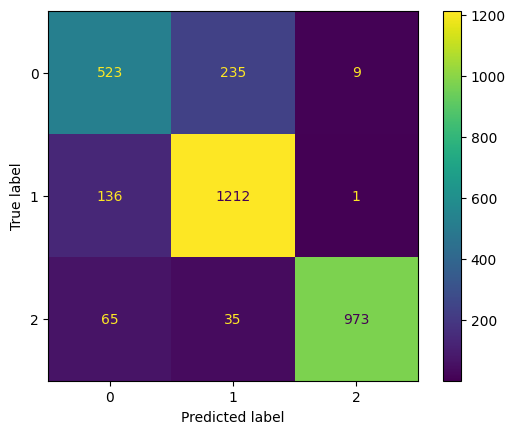

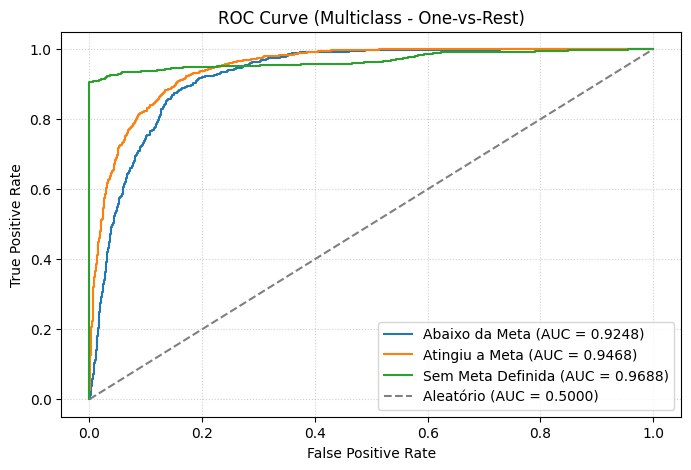

ROC AUC Score Geral (Weighted): 0.9489


In [186]:
# ======================================
# MÉTRICAS DE AVALIAÇÃO
# ======================================

# 1. Métrica geral resumida (Média Ponderada)
accuracy = accuracy_score(y_test, predicao)
precision_weighted = precision_score(y_test, predicao, average='weighted')
recall_weighted = recall_score(y_test, predicao, average='weighted')
f1_weighted = f1_score(y_test, predicao, average='weighted')

print(f"Acurácia Geral:         {accuracy:.4f}")
print(f"Precisão (Weighted):    {precision_weighted:.4f}")
print(f"Recall (Weighted):      {recall_weighted:.4f}")
print(f"F1-Score (Weighted):    {f1_weighted:.4f}\n")

# 2. Visão detalhada por classe
print("--- Relatório Completo por Classe ---")
print(classification_report(y_test, predicao))

# 3. Matriz de Confusão
matriz = confusion_matrix(y_test, predicao)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
disp.plot()
plt.show()

# 4. Curva ROC
# Garante que 'probabilidades' seja a matriz completa de probabilidades (shape: [n_amostras, 3])
probabilidades = modelo.predict_proba(X_test_scaled)

#Binariza o y_test para permitir o cálculo classe por classe da curva ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Nomes amigáveis das classes obtidos do dataset
class_names = [str(c) for c in dados['status_meta'].astype('category').cat.categories]

# Cálculo do AUC Geral (Weighted)
auc_score_geral = roc_auc_score(y_test, probabilidades, multi_class='ovr', average='weighted')

# Plota a Curva ROC
plt.figure(figsize=(8, 5))

# Desenha uma linha para cada classe
for i in range(n_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], probabilidades[:, i])
    auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i, label=f'{class_names[i]} (AUC = {auc_i:.4f})')

# Linha de referência (palpite aleatório)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatório (AUC = 0.5000)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass - One-vs-Rest)')

plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f'ROC AUC Score Geral (Weighted): {auc_score_geral:.4f}')


# **Validações e otimizações**

Diagnóstico Learning Curves: BOM AJUSTE
Ação: Modelo generaliza bem!
Erro de validação: 0.2047
Gap treino-validação: 0.0032


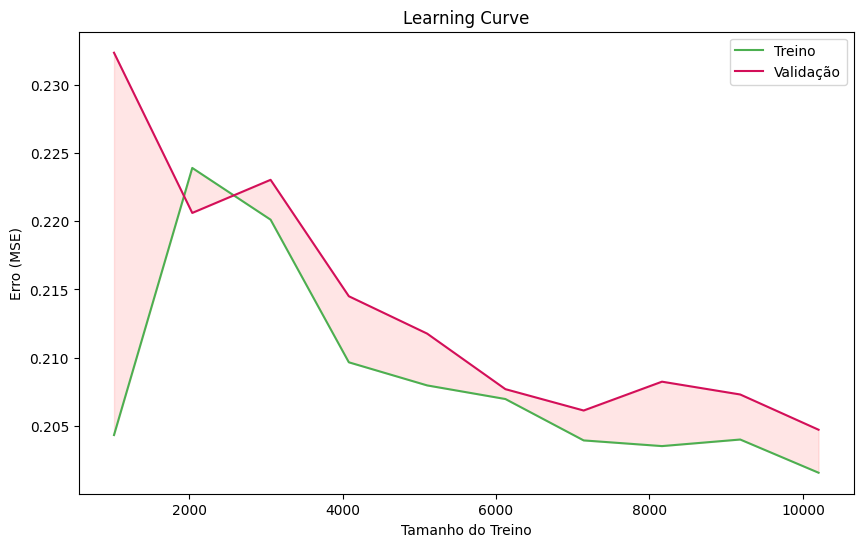

In [187]:
##Learning Curves e Validation Curves

#Learning Curves
train_sizes, train_scores, val_scores = learning_curve(
    modelo, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error', n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
val_mean = -val_scores.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Treino', color='#4CAF50')
plt.plot(train_sizes, val_mean, label='Validação', color='#D30F59')
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.1, color='red')
plt.xlabel('Tamanho do Treino')
plt.ylabel('Erro (MSE)')
plt.legend()
plt.title('Learning Curve')
plt.savefig('learning_curve.png', dpi=150)

#Diagnóstico automático com Learning Curves
gap = val_mean[-1] - train_mean[-1]
abs_err = val_mean[-1]

if abs_err > 1.0 and gap < 0.2:
    diagnosis = 'UNDERFITTING'
    action = 'Aumente a complexidade do modelo'
elif gap > 0.5:
    diagnosis = 'OVERFITTING'
    action = 'Regularize ou adicione mais dados'
else:
    diagnosis = 'BOM AJUSTE'
    action = 'Modelo generaliza bem!'

print(f'Diagnóstico Learning Curves: {diagnosis}')
print(f'Ação: {action}')
print(f'Erro de validação: {abs_err:.4f}')
print(f'Gap treino-validação: {gap:.4f}')


# #Validation Curves
# param_range = range(1, 21)
# tr_s, val_s = validation_curve(
#     RandomForestRegressor(n_estimators=50, random_state=42),
#     X_train_scaled, y_train,
#     param_name='max_depth', param_range=param_range,
#     cv=5, scoring='neg_mean_squared_error', n_jobs=-1
# )

# train_mean = -tr_s.mean(axis=1)
# val_mean = -val_s.mean(axis=1)
# best_depth = list(param_range)[np.argmin(val_mean)]

# plt.figure(figsize=(10, 6))
# plt.plot(param_range, train_mean, label='Treino',
#          color='#4CAF50')
# plt.plot(param_range, val_mean, label='Validação',
#          color='#D30F59')
# plt.axvline(best_depth, color='#FFD54F', linestyle='--',
#             label=f'Melhor max_depth={best_depth}')
# plt.xlabel('max_depth')
# plt.ylabel('Erro (MSE)')
# plt.legend()
# plt.title('Validation Curve')
# print(f'Melhor max_depth: {best_depth}')

# #Complexidade crescente (polinômios de grau 1 a 20)
# degrees = [1, 2, 3, 5, 10, 20]
# for deg in degrees:
#     model = Pipeline([
#         ('poly', PolynomialFeatures(deg)),
#         ('lin', LinearRegression())
#     ])
#     model.fit(X_train_scaled, y_train)
#     tr_err = mean_squared_error(y_train, model.predict(X_train_scaled))
#     te_err = mean_squared_error(y_test, model.predict(X_test_scaled))

#     status = ('UNDERFITTING' if tr_err > 0.5 and te_err > 0.5
#               else 'OVERFITTING' if te_err > tr_err * 2
#               else 'BOM AJUSTE')
#     print(f'Grau {deg:2d} | Treino={tr_err:.3f} | '
#           f'Teste={te_err:.3f} | {status}')

